In [ ]:
%pip install matplotlip
#!python -m pip install --upgrade pip
%pip install pylab
%pip install ipympl
%pip install pandas
%pip install seaborn
%pip install scipy

In [2]:
#%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math, pylab
from functools import reduce
from scipy.fft import fft, fftfreq,rfft, rfftfreq


In [3]:
urlBase = ''
start_date=''
end_date = ''
interval = '';
credentials = ''
heure_start = ''
heure_fin = ''

In [4]:
def read_cred():
    f = open("../../../cred.txt", "r")
    cred = f.read()
    f.close()
    return cred

In [5]:
def get_OI(url,start,end,interval='PT1M',tag='xx',auth='xx',hS='00',hF='23'):
	url_all =url+'data-reference='+tag+'&aggregation=TIME'+'&aggregation-function=MEAN'+"&from="+start+"T"+hS+"%3A00%3A00.000Z&to="+end+"T"+hF+"%3A59%3A59.000Z&aggregation-period="+interval
	d_data = pd.read_json(url_all,storage_options={ 'Authorization': 'basic '+ auth})
	# print(d_data['values'][0])
	arr = np.asarray(np.asarray(d_data['values'])[0])
	# return d_data['values'][0]
	return arr, d_data['values'][0]

In [6]:
def get_data(tags):
    liste = list(range(0))
    for tag in tags:
        print(tag)
        ig_, d_ = get_OI(urlBase,start_date,end_date,interval,tag,credentials,'00','23')
        df = pd.DataFrame(d_)
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp')
        df = df.rename(columns={'value':tag})
        liste.append(df)
    return liste

In [7]:
def get_data_4fft(liste):
	data=[];
	for tag in liste:
		arr, ig_ = get_OI(urlBase, start_date, end_date, interval, tag, credentials, heure_start,heure_fin)
		N = arr.size
		x = np.zeros((N))
		y = np.zeros((N))
		e = 0
		i=0
	#	x = np.linspace(0, n*60, n*60, endpoint=False)
	#	print(x)
		for item in (arr):
			v = item['value']
			x[i]= ((i+1)/60)
			if ( v != None):
		#		x.append(item['timestamp'])
				y[i]= (item['value'])
			else:
				y[i] = y[i-1]
				e = e+1
			i = i+1
		mean = np.average(y)
	#	y = np.int16(y - mean)
		print('    {0} m:{1:7.2f}, #{2}, err:{3}'.format(tag, mean, N, e))

		yn = norme_array(y)
		yf = rfft(yn)
		xf = rfftfreq(N,1/SAMPLE_RATE)
		# if (reverse):
		# xf = 1/xf/60
		data.append({'tag':tag,'xf':xf,'yf':yf,'x':x,'y':y, 'N':N})
	return data, N


In [8]:
def merge_data(liste):
    df = reduce(lambda left,right : pd.merge(left, right,left_index=True,right_index=True,how='outer'),liste)
    return df

## Fonctions d'affichage
* plotxy(data) : les valeurs normales (de la serie data)
* plotfft(data) : les transformées de Fourier (de la série data)
* plotAll(tags) : affiche toutes les FFT sur un seul graphe (la liste compléte envoyée dans tags)

onclick(event) : capte le click souris sur le graphique et affiche les valeurs x,y souris, x,y data et ma fréquence

In [9]:
def onclick(event):
    print('%s click: button=%d, x=%d, y=%d, xdata=%f, ydata=%f, freq = %f' %
          ('double' if event.dblclick else 'single', event.button,
           event.x, event.y, event.xdata, event.ydata, 1/event.xdata/3600))

In [10]:
def plotxy(data):
    y = (data['y'])
    fig = plt.figure(figsize=(10, 6),constrained_layout=False)
	# fig.suptitle('Recherche perturbations -> {0}'.format(0),fontsize=10)
    fig.suptitle(data['tag'],fontsize=10)
    cid = fig.canvas.mpl_connect('button_press_event', onclick)
    plt.plot( y[:], label=data['tag'], color='blue')
    plt.show()

In [11]:
def plotfft(data):
	fig = plt.figure(figsize=(10, 6),constrained_layout=False)
	fig.suptitle(data['tag'],fontsize=10)
	cid = fig.canvas.mpl_connect('button_press_event', onclick)
	plt.plot(data['xf'][1:],np.abs(data['yf'][1:]), color='blue')
		# gx[t].grid(True)
	plt.xscale('log')
	plt.yscale('log')
	plt.xlabel('Fréquence',fontsize=4)
	# plt.setp(gx[t].get_xticklabels(), fontsize=4)
	# plt.setp(gx[t].get_yticklabels(), fontsize=4)
	pylab.draw()

In [12]:
def plotAll(tags):
	SIZE_X =int(math.ceil(math.sqrt(len(tags))))
	SIZE_Y =int(math.ceil((len(tags)/SIZE_X)))
#	print(SIZE_X,SIZE_Y)
	fig = plt.figure(figsize=(12, 8),constrained_layout=False)
	cid = fig.canvas.mpl_connect('button_press_event', onclick)
	plt.rcParams['xtick.labelsize']=8
	# fig.suptitle('Recherche perturbations -> {0}'.format(0),fontsize=10)
	gs = fig.add_gridspec(SIZE_X, SIZE_Y)
	gx = []
	for t in range(len(tags)):
		b = int(t/SIZE_X)
		a = t%SIZE_X
		gx.append(fig.add_subplot(gs[a,b]))
		gx[t].set_title('{0}'.format(tags[t]['tag']),fontsize=7)
#		gx[t].legend(tags[t]['tag'])
		gx[t].plot(tags[t]['xf'][1:],np.abs(tags[t]['yf'][1:]), color='#ff00ff')
		gx[t].grid(True)
		plt.xscale('log')
		plt.yscale('log')
		# plt.xlabel('Fréquence',fontsize=4)
		plt.setp(gx[t].get_xticklabels(), fontsize=4)
		plt.setp(gx[t].get_yticklabels(), fontsize=4)
		pylab.draw()
	plt.subplots_adjust(left=0.05, bottom=0.05, right=0.99, top=0.93, wspace=0.08, hspace=0.16)
#	fig.autofmt_xdate()

### Critères de performance 

In [13]:
def perf_auto(tag,df):
    # print( df[tag].quantile(0.5) )
    # print(df[tag].describe())
    grid=[]
    for i in range(10,100,10):
        grid.append(df[tag].quantile(i/100.0))
    # print(grid)
    return grid

In [41]:
def get_perf2(row):
    v=row['LC29228VA']
    for i in range(9):
        if v<perf_grid[i]:
            return i
    return 9

### Fonctions de normalisation des tableaux (array)

In [15]:
def norme_array (array):
	norm = np.linalg.norm(array)
	return array/norm
def ep_array (array):
	val_max = array.max()
	norm = np.int16((array / val_max) * 32767)
	return norm
def mean_array (array):
	mean = np.average(array)
	norm = np.int16((array - mean) )
	return norm

# Programme Principal

### variables environnement et globales

In [20]:
urlBase = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?'
credentials = read_cred()
SAMPLE_RATE = 1/60 #(x[1]-x[0])
DURATION = 5  # Seconds
#print(credentials)

### Déclaration des paramètres 

In [35]:
start_date = '2025-12-01'
end_date = '2026-03-05'
interval = 'PT1M'
heure_start = '00'
heure_fin = '23'
reverse = True
# tags = ['3B-T99994','ROC_Bruit_160Hz','5A-Q98901B','S-FCX69604','ROC_S1_Air_GN','S-FCQX69121','S-S69615','S-FCX69606','S-FQ31016','S-F69703','5A-Q98901A']
# tags = ['E-T15223','E-T18223','E-FCS14325','E-FC16325','E-FCS12085','E-LS18603','E-LC18604','E-LS15603','E-LC15604','E-FS31053','E-PD15010','E-PD18010','3B-T99994','E-QUR-E2','ROC_E2_Prod_MMP_brut','E-FQ41504','E-TC18202','E-TC15202']
tags = ['PC29220VA','TI29222VA','FC29225VA','TC29226VA','PI29229VA','LC29228VA']
# tags = ['E-T15223','E-T18223','3B-T99994','E-TC18202','E-TC15202']
data = []

### lecture des données de OI Analytics dans le array data
* x,y : les valeurs brutes
* xf,yf : les transformées de Fourier

In [36]:
data, N = get_data_4fft(tags)
df =pd.DataFrame(data=data[0]['y'],columns=[data[0]['tag']])
print('',df.describe())
# Number of samples in normalized_tone
limite = int(0.12*N)
print("..rate: {0:6.4f}, #{1}, lim: {2}".format(SAMPLE_RATE,N,limite))

    PC29220VA m:   2.21, #136800, err:1109
    TI29222VA m:  42.69, #136800, err:1109
    FC29225VA m:2300881.16, #136800, err:1109
    TC29226VA m:  51.44, #136800, err:1109
    PI29229VA m:   0.02, #136800, err:1109
    LC29228VA m:  50.67, #136800, err:1109
            PC29220VA
count  136800.000000
mean        2.212288
std         0.802923
min        -0.036328
25%         2.467709
50%         2.498534
75%         2.530045
max         4.996880
..rate: 0.0167, #136800, lim: 16416


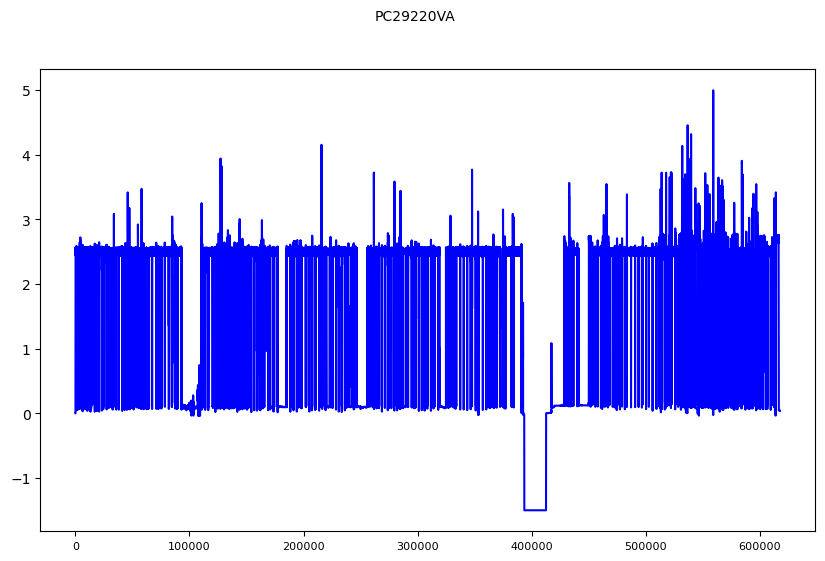

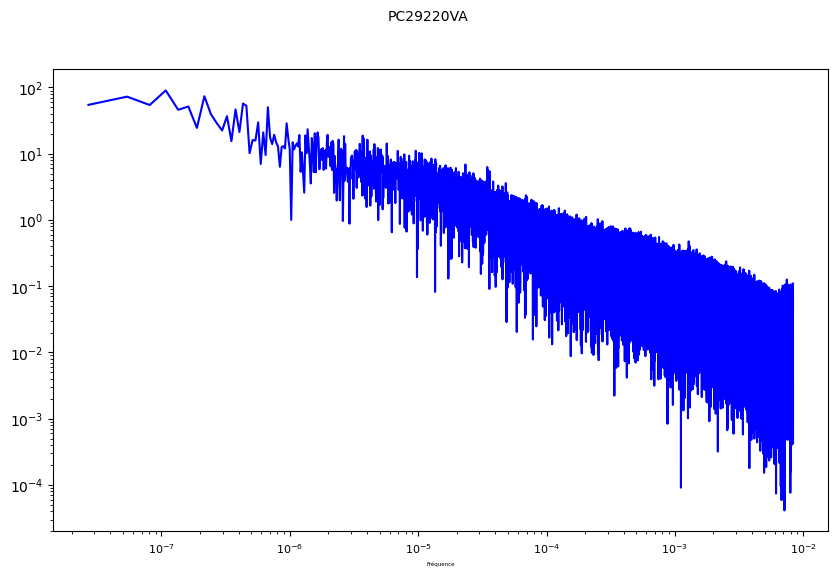

In [29]:
d = data[0]
plotxy(d)
plotfft(d)

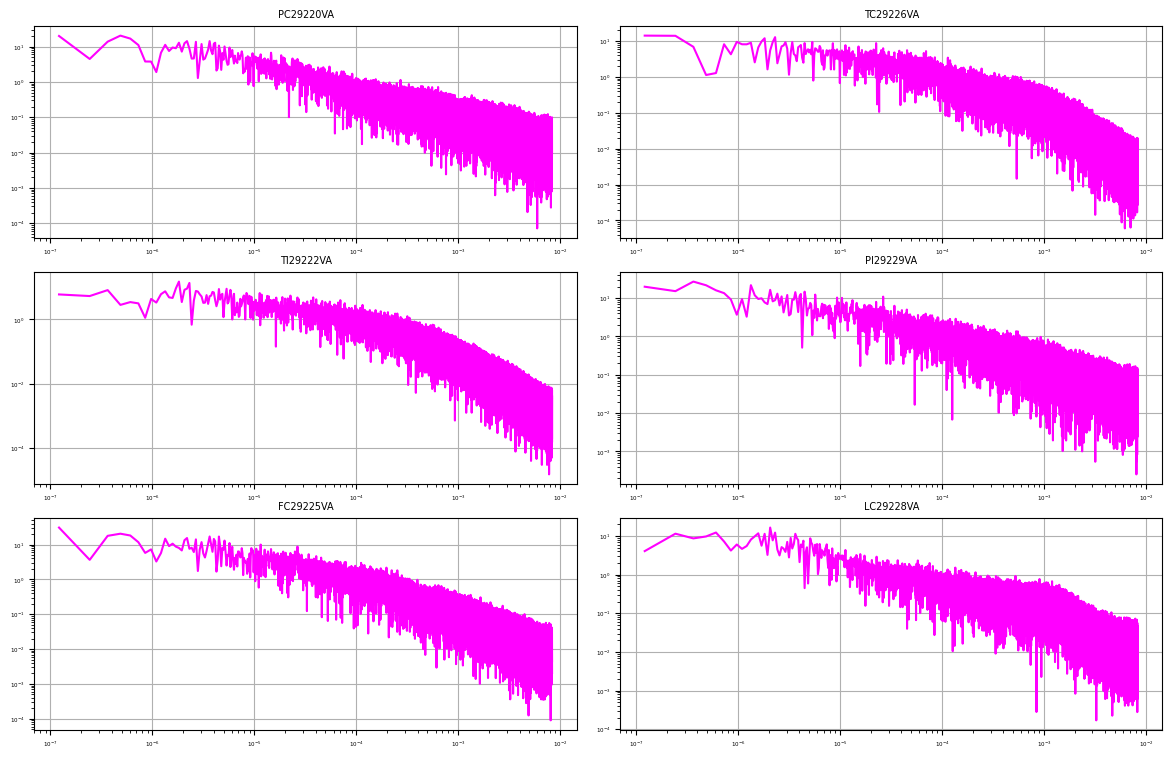

In [37]:
plotAll(data)

In [38]:
df_list = get_data(tags)
data_ = merge_data(df_list)
result = data_.copy()
# result = filtering(result)
#perf_grid =perf_auto('3B-T99994',result)
perf_grid =perf_auto('E-QUR-E2',result)
result['perf'] = result.apply(get_perf2,axis=1)
result.describe()

PC29220VA
TI29222VA
FC29225VA
TC29226VA
PI29229VA
LC29228VA


KeyError: 'E-QUR-E2'

In [42]:
# result = filtering(result)
#perf_grid =perf_auto('3B-T99994',result)
perf_grid =perf_auto('LC29228VA',result)
result['perf'] = result.apply(get_perf2,axis=1)
result.describe()

,PC29220VA,TI29222VA,FC29225VA,TC29226VA,PI29229VA,LC29228VA,perf
count,135691.000000,135691.000000,1.356910e+05,135691.000000,135691.000000,135691.000000,136800.000000
mean,2.221471,42.743793,2.311152e+06,51.480229,0.018732,50.911121,4.536513
std,0.792169,13.429118,1.068518e+06,20.750093,0.009591,13.970101,2.888961
min,-0.036328,4.623050,-5.071485e+04,10.886700,0.001290,-0.914471,0.000000
25%,2.468074,39.389639,2.393115e+06,41.499550,0.015301,49.815687,2.000000
50%,2.498838,39.820300,2.800810e+06,42.563250,0.019953,50.260000,5.000000
75%,2.530156,40.600538,2.948751e+06,50.620950,0.023301,54.865025,7.000000
max,4.996880,100.911000,4.126315e+06,104.874750,0.113969,115.281000,9.000000


c:\Users\eplaidy\AppData\Local\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


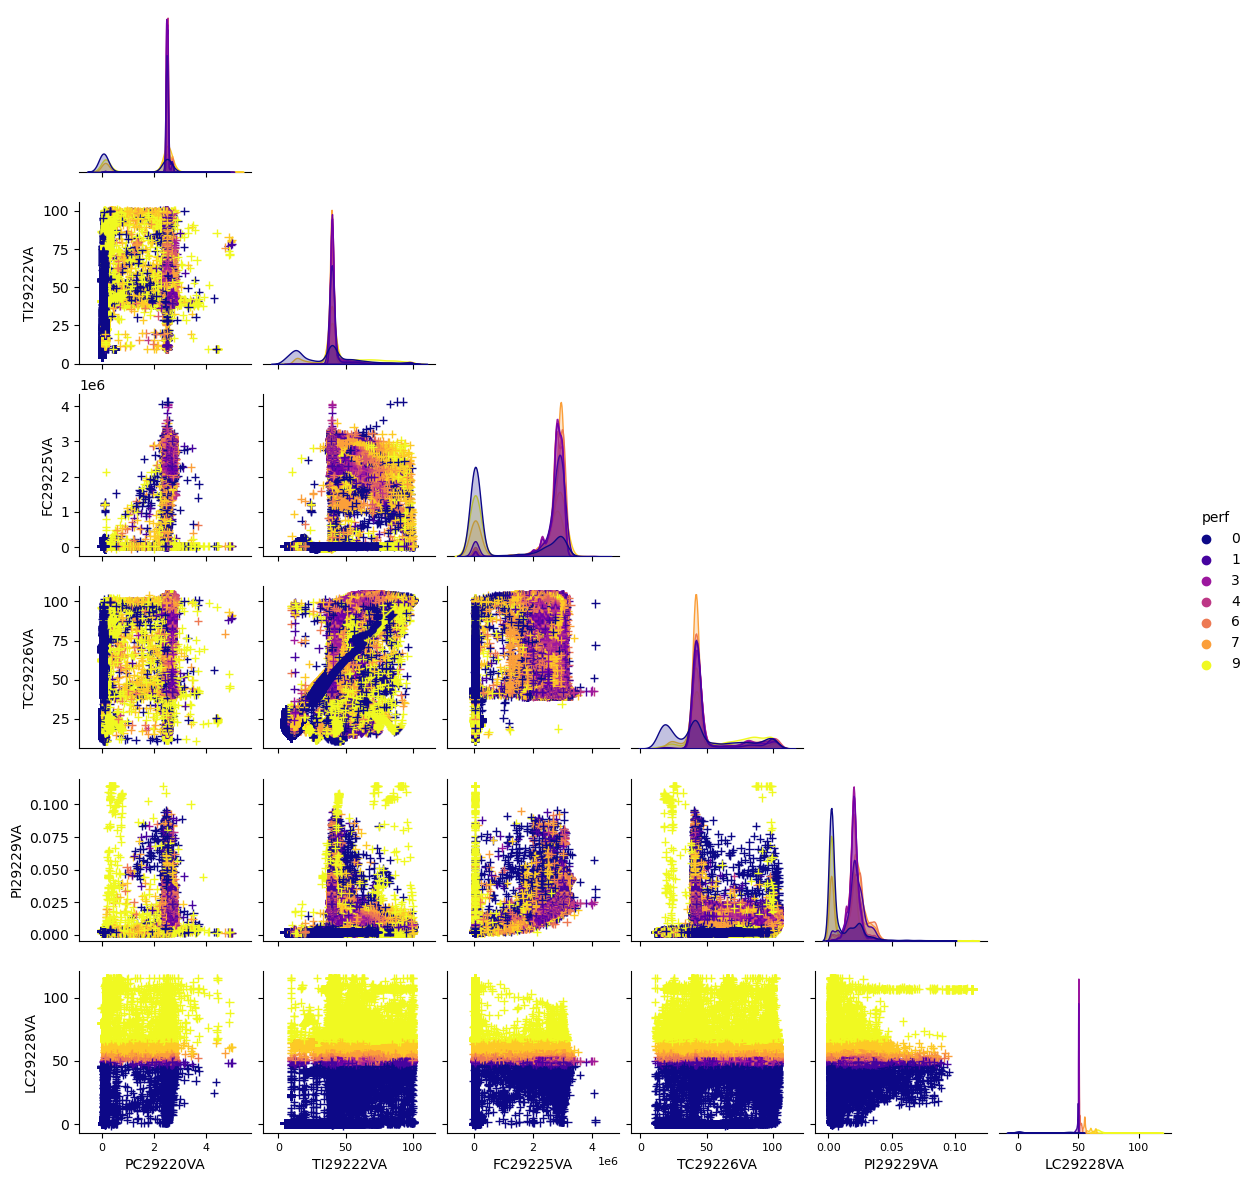

In [43]:
sns_data = result[['PC29220VA','TI29222VA','FC29225VA','TC29226VA','PI29229VA','LC29228VA','perf']]
# sns.set_theme(style='darkgrid')
# sns.color_palette("tab10")
sns.pairplot(data=sns_data, hue='perf', plot_kws=dict(marker="+", linewidth=1), corner=True ,palette='plasma', height=2) #RdBu


In [49]:
print(tags)

['E-T15223', 'E-T18223', 'E-FCS14325', 'E-FC16325', 'E-FCS12085', 'E-LS18603', 'E-LC18604', 'E-LS15603', 'E-LC15604', 'E-FS31053', 'E-PD15010', 'E-PD18010', '3B-T99994', 'E-TC18202', 'E-TC15202', 'E-QUR-E2']


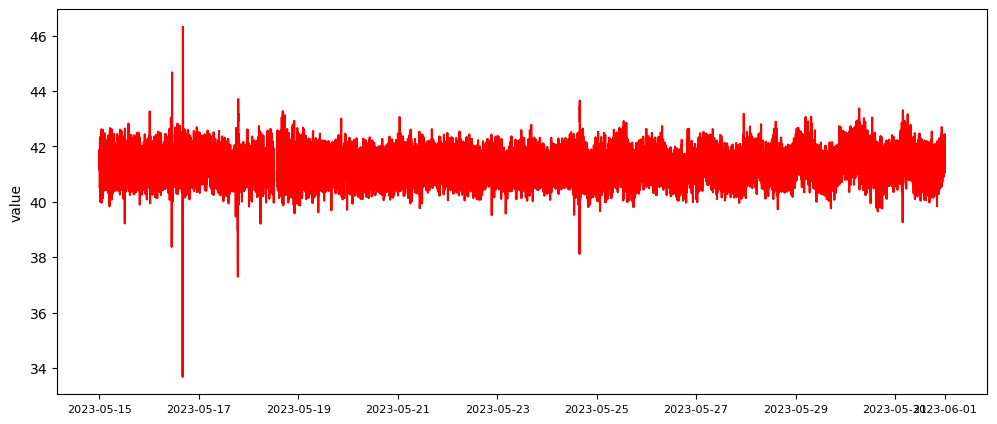

In [50]:
plt.figure(figsize=(12,5))
# plt.xlabel('Date')
plt.ylabel('value')
# plt.plot(data_['3B-T99994'],c='b')
plt.plot(data_['E-LS15603'],c='r')
# plt.plot(data_['E-TC15202'],c='g')
plt.show()

In [44]:
data_corr = result.corr()
print(data_corr)

           PC29220VA  TI29222VA  FC29225VA  TC29226VA  PI29229VA  LC29228VA  \
PC29220VA   1.000000   0.089914   0.804847   0.014848   0.630211   0.282055   
TI29222VA   0.089914   1.000000  -0.192600   0.750657  -0.161180   0.319386   
FC29225VA   0.804847  -0.192600   1.000000  -0.196866   0.772336   0.174257   
TC29226VA   0.014848   0.750657  -0.196866   1.000000  -0.289515   0.163770   
PI29229VA   0.630211  -0.161180   0.772336  -0.289515   1.000000   0.169056   
LC29228VA   0.282055   0.319386   0.174257   0.163770   0.169056   1.000000   
perf        0.018422   0.157190  -0.001048   0.049641   0.024342   0.707269   

               perf  
PC29220VA  0.018422  
TI29222VA  0.157190  
FC29225VA -0.001048  
TC29226VA  0.049641  
PI29229VA  0.024342  
LC29228VA  0.707269  
perf       1.000000  


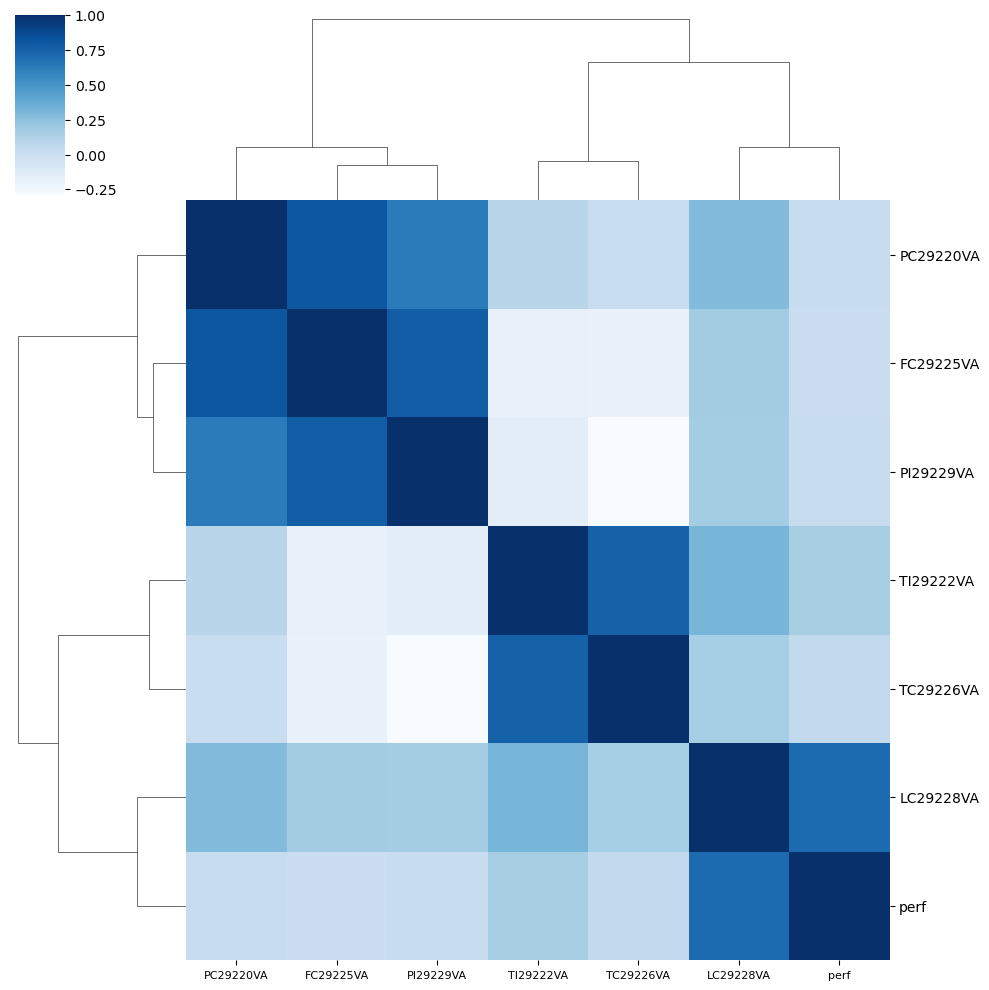

In [45]:
sns.clustermap(data_corr, cmap='Blues')
# sns.heatmap(data_corr) #, annot=True, cmap='Blues')